<a href="https://colab.research.google.com/github/vadim-vic/Causal-Inference/blob/main/code_dag_likelihood/DAG_diffusion_flow_generative_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAG Generation and Diffusion Model

## 1. Generate a collection of DAGs

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

In [12]:
def generate_random_dag(num_nodes, edge_probability):
    """Generates a random Directed Acyclic Graph (DAG)."""
    G = nx.DiGraph()
    nodes = list(range(num_nodes))
    G.add_nodes_from(nodes)

    # Iterate through nodes to add edges, ensuring acyclicity
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            if np.random.rand() < edge_probability:
                G.add_edge(i, j)
    return G

# Parameters for DAG generation
NUM_DAGS = 100  # Number of DAGs in the collection
NUM_NODES_PER_DAG = 8 # Number of nodes in each DAG (changed from 5 to 8 to avoid U-Net dimension collapse)
EDGE_PROBABILITY = 0.4 # Probability of an edge existing between two nodes

# Generate a collection of DAGs
dag_collection = []
for _ in range(NUM_DAGS):
    dag_collection.append(generate_random_dag(NUM_NODES_PER_DAG, EDGE_PROBABILITY))

print(f"Generated {NUM_DAGS} DAGs with {NUM_NODES_PER_DAG} nodes each.")

Generated 100 DAGs with 8 nodes each.


### Visualize a few example DAGs

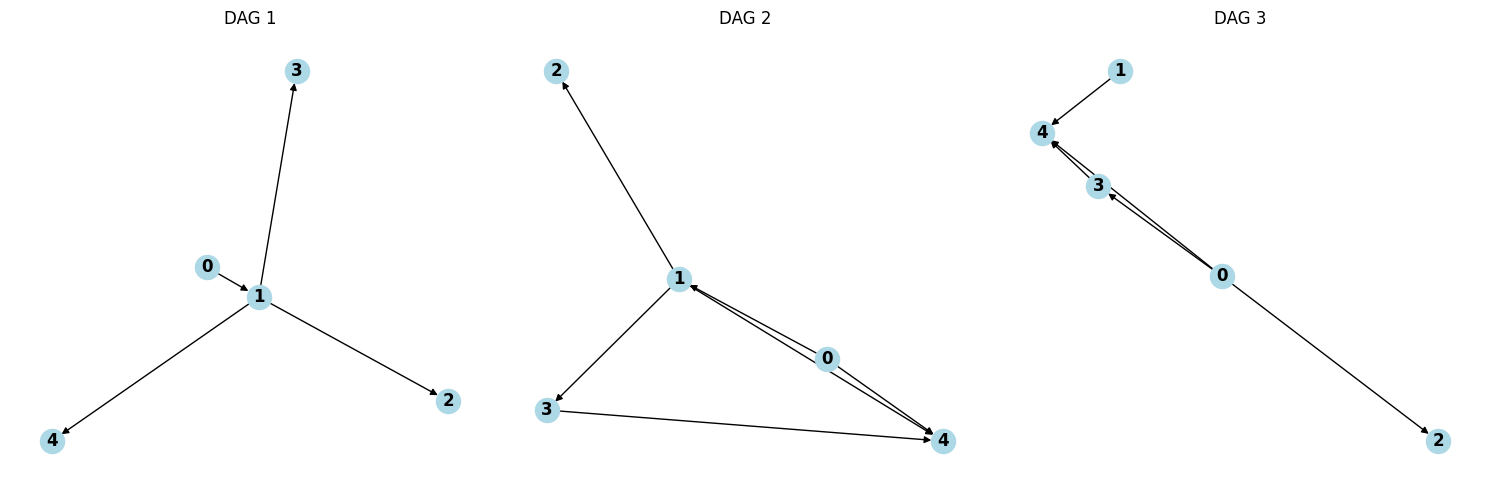

In [3]:
plt.figure(figsize=(15, 5))
for i in range(min(3, NUM_DAGS)): # Display up to 3 DAGs
    plt.subplot(1, min(3, NUM_DAGS), i + 1)
    pos = nx.spring_layout(dag_collection[i]) # Layout for visualization
    nx.draw(dag_collection[i], pos, with_labels=True, node_color='lightblue', font_weight='bold')
    plt.title(f"DAG {i+1}")
plt.tight_layout()
plt.show()

## 2. Enumerate each DAG in the collection and 3. Make the number the label.

Each DAG in the `dag_collection` is implicitly enumerated by its index in the list. This index can serve as a unique label for each DAG. For training a generative model, we will likely need to convert these graph structures into a numerical format, such as adjacency matrices. These matrices will be the input to our diffusion model, and the enumeration (or implicit label) will be used to keep track of individual DAGs during training and evaluation.

In [13]:
# Convert DAGs to adjacency matrices
adjacency_matrices = []
for i, dag in enumerate(dag_collection):
    # Ensure the adjacency matrix has a consistent size (NUM_NODES_PER_DAG x NUM_NODES_PER_DAG)
    adj_matrix = nx.to_numpy_array(dag, nodelist=list(range(NUM_NODES_PER_DAG)))
    adjacency_matrices.append(adj_matrix)

# The labels are implicitly the indices of the DAGs in the collection (0 to NUM_DAGS-1)
labels = np.arange(NUM_DAGS)

print(f"Created {len(adjacency_matrices)} adjacency matrices.")
print(f"Shape of the first adjacency matrix: {adjacency_matrices[0].shape}")
print("First adjacency matrix (for DAG 0):")
print(adjacency_matrices[0])

Created 100 adjacency matrices.
Shape of the first adjacency matrix: (8, 8)
First adjacency matrix (for DAG 0):
[[0. 1. 0. 1. 1. 1. 0. 1.]
 [0. 0. 0. 1. 1. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


## 4. Create a diffusion flow generative model

For this, we'll implement a basic Denoising Diffusion Probabilistic Model (DDPM) for generating adjacency matrices. The process involves defining a forward diffusion process (adding noise) and a reverse process (denoising using a neural network).

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Ensure reproducibility for PyTorch as well
torch.manual_seed(42);
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42);

# Convert adjacency matrices to PyTorch tensors
# Stack them to create a batch dimension
data_tensor = torch.tensor(np.array(adjacency_matrices), dtype=torch.float32);

# Add a channel dimension for consistency with typical CNN inputs, even if not used as CNN yet
# Shape will be (NUM_DAGS, 1, NUM_NODES_PER_DAG, NUM_NODES_PER_DAG)
data_tensor = data_tensor.unsqueeze(1);

print(f"Data tensor shape: {data_tensor.shape}")

Data tensor shape: torch.Size([100, 1, 8, 8])


### Define the Diffusion Model Parameters and Scheduler

We'll define the number of diffusion steps and a simple linear noise schedule.

In [19]:
class LinearNoiseScheduler:
    def __init__(self, timesteps, beta_start=0.0001, beta_end=0.02):
        self.timesteps = timesteps
        self.betas = torch.linspace(beta_start, beta_end, timesteps)
        self.alphas = 1. - self.betas
        self.alphas_prod = torch.cumprod(self.alphas, axis=0)
        self.alphas_prod_prev = torch.cat([torch.tensor([1.0]), self.alphas_prod[:-1]])
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        self.sqrt_alphas_prod = torch.sqrt(self.alphas_prod)
        self.sqrt_one_minus_alphas_prod = torch.sqrt(1. - self.alphas_prod)
        self.posterior_variance = self.betas * (1. - self.alphas_prod_prev) / (1. - self.alphas_prod)

    def add_noise(self, x_start, t, noise):
        # x_t = sqrt(alpha_prod_t) * x_0 + sqrt(1 - alpha_prod_t) * noise
        # Reshape for broadcasting: [batch_size] -> [batch_size, 1, 1, 1]
        sqrt_alphas_prod_t = self.sqrt_alphas_prod[t].view(-1, 1, 1, 1).to(x_start.device)
        sqrt_one_minus_alphas_prod_t = self.sqrt_one_minus_alphas_prod[t].view(-1, 1, 1, 1).to(x_start.device)
        return sqrt_alphas_prod_t * x_start + sqrt_one_minus_alphas_prod_t * noise

    def sample_prev_timestep(self, x_t, t, model_output):
        # Equation for sampling x_{t-1} from x_t and model output (epsilon_theta)
        # Reshape for broadcasting: [batch_size] -> [batch_size, 1, 1, 1]
        beta_t = self.betas[t].view(-1, 1, 1, 1).to(x_t.device)
        alpha_t = self.alphas[t].view(-1, 1, 1, 1).to(x_t.device)
        sqrt_one_minus_alphas_prod_t = self.sqrt_one_minus_alphas_prod[t].view(-1, 1, 1, 1).to(x_t.device)
        sqrt_recip_alpha_t = self.sqrt_recip_alphas[t].view(-1, 1, 1, 1).to(x_t.device)

        model_mean = sqrt_recip_alpha_t * (x_t - beta_t * model_output / sqrt_one_minus_alphas_prod_t)
        posterior_variance_t = self.posterior_variance[t].view(-1, 1, 1, 1).to(x_t.device)

        # The 't' here is a tensor of timesteps (all identical for a given loop iteration).
        # We need to extract a scalar value for the conditional check.
        if t.min().item() == 0: # Check if the current timestep is 0
            return model_mean
        else:
            noise = torch.randn_like(x_t)
            return model_mean + torch.sqrt(posterior_variance_t) * noise


TIMESTEPS = 1000 # Number of diffusion steps
noise_scheduler = LinearNoiseScheduler(timesteps=TIMESTEPS)

print(f"Diffusion process defined with {TIMESTEPS} timesteps.")

Diffusion process defined with 1000 timesteps.


### Define the U-Net Denoising Model

We will use a simple U-Net architecture to learn the reverse diffusion process, i.e., to denoise the noisy adjacency matrices.

In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Pad x1 to match the shape of x2
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = torch.nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1);
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, num_nodes, time_embedding_dim=256):
        super().__init__()
        self.inc = DoubleConv(1, 64) # Input is 1 channel (adjacency matrix)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.up1 = Up(512 + 256, 256)
        self.up2 = Up(256 + 128, 128)
        self.up3 = Up(128 + 64, 64)
        self.outc = OutConv(64, 1) # Output is 1 channel (denoised adjacency matrix)

        # Time embedding to condition the U-Net on the current timestep
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_embedding_dim),
            nn.ReLU(),
            nn.Linear(time_embedding_dim, 1) # Output directly added to the U-Net output or input
        )

    def forward(self, x, t):
        # t is a scalar indicating the timestep. We'll broadcast it to match x's shape.
        # This simple time conditioning might need to be more sophisticated for better performance.
        time_emb = self.time_mlp(t.float().unsqueeze(-1)).view(-1, 1, 1, 1) # Reshape for broadcasting

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)
        logits = self.outc(x)

        # Add time embedding to the output logits (or some intermediate layer)
        return logits + time_emb

# Initialize the model
model = UNet(num_nodes=NUM_NODES_PER_DAG);
print("U-Net Denoising Model initialized.")

U-Net Denoising Model initialized.


## 5. Train the model on the collection of DAGs

In [16]:
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Using device: {device}")

# Prepare data for training
# Create a TensorDataset from the data_tensor
dataset = TensorDataset(data_tensor)
# Create a DataLoader for batching and shuffling
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Optimizer and Loss Function
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training Loop Parameters
epochs = 50 # Number of training epochs

print(f"Starting training for {epochs} epochs...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in dataloader:
        x_start = batch[0].to(device) # Original adjacency matrices

        optimizer.zero_grad()

        # Sample a random timestep for each item in the batch
        t = torch.randint(0, TIMESTEPS, (x_start.shape[0],), device=device).long()

        # Generate random noise
        noise = torch.randn_like(x_start);

        # Add noise to the clean image at the sampled timestep
        x_noisy = noise_scheduler.add_noise(x_start, t, noise);

        # Predict the noise using the U-Net model
        predicted_noise = model(x_noisy, t);

        # Calculate the loss (MSE between actual and predicted noise)
        loss = loss_fn(predicted_noise, noise);
        total_loss += loss.item();

        # Backpropagation and optimization
        loss.backward();
        optimizer.step();

    avg_loss = total_loss / len(dataloader);
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}");

print("Training complete!")

Using device: cpu
Starting training for 50 epochs...
Epoch 1/50, Loss: 299.0398
Epoch 2/50, Loss: 109.0506
Epoch 3/50, Loss: 75.0390
Epoch 4/50, Loss: 44.1578
Epoch 5/50, Loss: 21.3069
Epoch 6/50, Loss: 9.4159
Epoch 7/50, Loss: 13.4284
Epoch 8/50, Loss: 9.2077
Epoch 9/50, Loss: 14.7389
Epoch 10/50, Loss: 8.0068
Epoch 11/50, Loss: 5.0928
Epoch 12/50, Loss: 4.1290
Epoch 13/50, Loss: 3.5050
Epoch 14/50, Loss: 3.3480
Epoch 15/50, Loss: 2.1745
Epoch 16/50, Loss: 1.9689
Epoch 17/50, Loss: 1.0533
Epoch 18/50, Loss: 0.8398
Epoch 19/50, Loss: 1.0337
Epoch 20/50, Loss: 0.7247
Epoch 21/50, Loss: 0.7563
Epoch 22/50, Loss: 0.6021
Epoch 23/50, Loss: 0.3593
Epoch 24/50, Loss: 0.4742
Epoch 25/50, Loss: 0.6524
Epoch 26/50, Loss: 0.5086
Epoch 27/50, Loss: 0.3446
Epoch 28/50, Loss: 0.5515
Epoch 29/50, Loss: 0.4007
Epoch 30/50, Loss: 0.3995
Epoch 31/50, Loss: 0.5974
Epoch 32/50, Loss: 0.3705
Epoch 33/50, Loss: 0.4795
Epoch 34/50, Loss: 0.4204
Epoch 35/50, Loss: 0.3464
Epoch 36/50, Loss: 0.7252
Epoch 37/50

## 6. Visualize the ground truth and the restored DAGs

Generated 5 adjacency matrices.


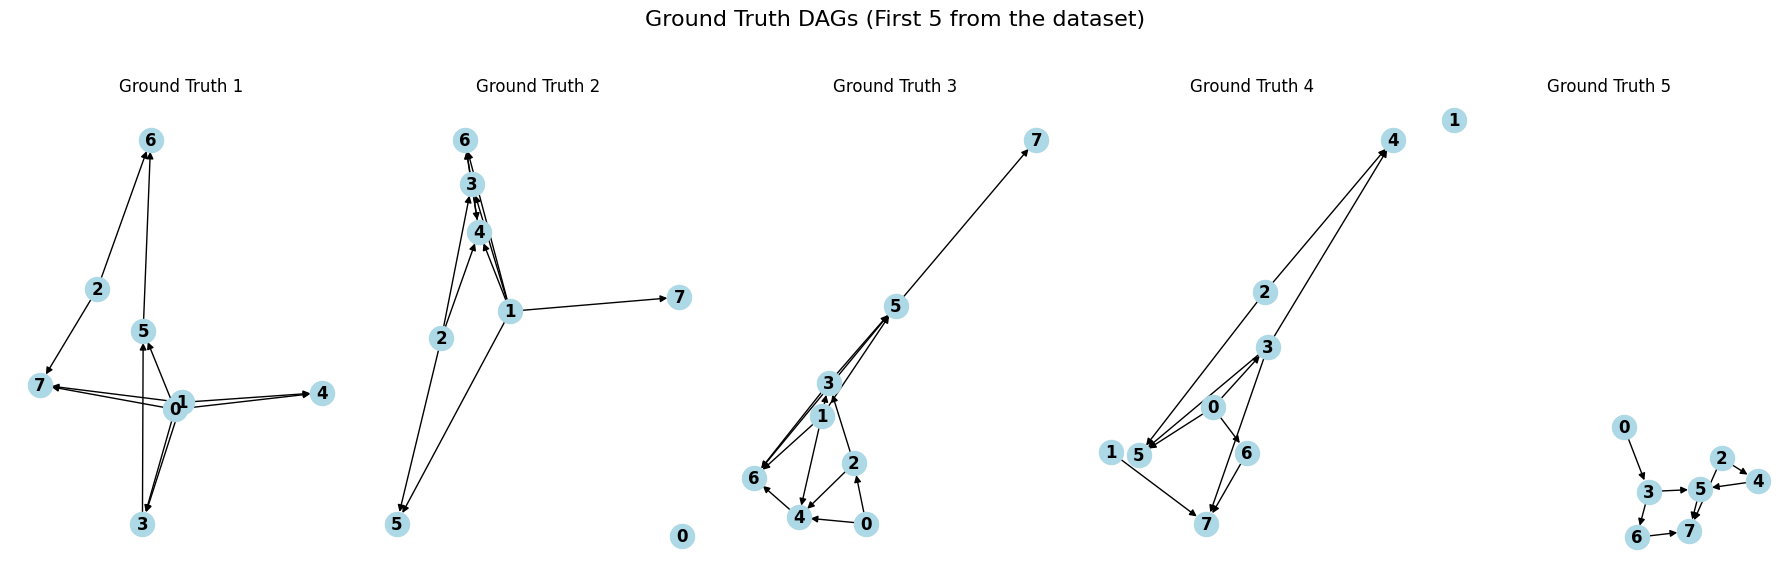

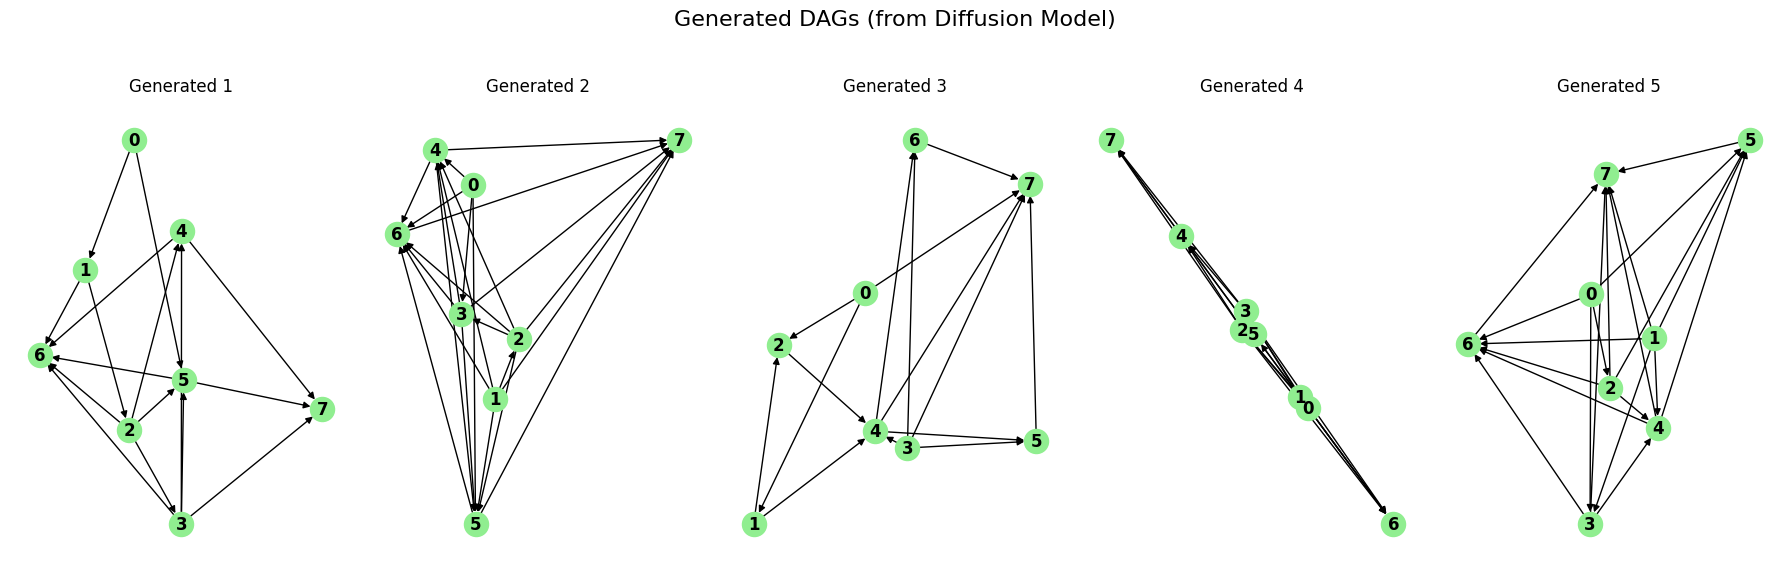

In [20]:
@torch.no_grad()
def sample_diffusion_model(model, noise_scheduler, num_samples, num_nodes, timesteps, device):
    model.eval()
    # Start with pure noise
    x_t = torch.randn(num_samples, 1, num_nodes, num_nodes, device=device)

    # Denoise step by step
    for t in reversed(range(timesteps)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
        predicted_noise = model(x_t, t_tensor)
        x_t = noise_scheduler.sample_prev_timestep(x_t, t_tensor, predicted_noise)

    # Post-processing: Convert adjacency matrix values to binary (0 or 1)
    # and ensure acyclicity if necessary (though the model might learn this implicitly)
    # For simplicity, we'll just threshold the output for now.
    generated_matrices = (x_t.squeeze(1) > 0.5).float()
    return generated_matrices

# Sample some DAGs from the trained model
num_samples_to_visualize = 5 # Display 5 generated DAGs

generated_adjacency_matrices = sample_diffusion_model(model, noise_scheduler,
                                                    num_samples_to_visualize,
                                                    NUM_NODES_PER_DAG, TIMESTEPS, device)

print(f"Generated {num_samples_to_visualize} adjacency matrices.")

# Convert generated adjacency matrices back to NetworkX DAGs for visualization
generated_dags = []
for adj_matrix_tensor in generated_adjacency_matrices:
    adj_matrix_np = adj_matrix_tensor.cpu().numpy()
    G = nx.from_numpy_array(adj_matrix_np, create_using=nx.DiGraph)
    # Remove self-loops if any were generated (shouldn't happen with the current generation method)
    G.remove_edges_from(nx.selfloop_edges(G))

    # Ensure acyclicity for generated graphs (diffusion models don't guarantee this inherently)
    # This is a common post-processing step for graph generation models.
    # A simple way is to keep only edges (u,v) where u < v to force an ordering.
    # This assumes nodes are ordered 0 to N-1.
    acyclic_G = nx.DiGraph()
    acyclic_G.add_nodes_from(G.nodes())
    for u, v in G.edges():
        if u < v: # Enforce topological ordering to ensure acyclicity
            acyclic_G.add_edge(u, v)
    generated_dags.append(acyclic_G)


# Visualize Ground Truth DAGs
plt.figure(figsize=(18, 6))
plt.suptitle("Ground Truth DAGs (First 5 from the dataset)", fontsize=16)
for i in range(num_samples_to_visualize):
    plt.subplot(1, num_samples_to_visualize, i + 1)
    # Use the spring layout or a custom layout for consistency
    pos = nx.spring_layout(dag_collection[i])
    nx.draw(dag_collection[i], pos, with_labels=True, node_color='lightblue', font_weight='bold')
    plt.title(f"Ground Truth {i+1}")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Visualize Restored/Generated DAGs
plt.figure(figsize=(18, 6))
plt.suptitle("Generated DAGs (from Diffusion Model)", fontsize=16)
for i in range(num_samples_to_visualize):
    plt.subplot(1, num_samples_to_visualize, i + 1)
    # Use the same layout for fair comparison, or spring_layout for each generated graph
    pos = nx.spring_layout(generated_dags[i])
    nx.draw(generated_dags[i], pos, with_labels=True, node_color='lightgreen', font_weight='bold')
    plt.title(f"Generated {i+1}")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 6. Visualize the ground truth and the restored DAGs

In [10]:
@torch.no_grad()
def sample_diffusion_model(model, noise_scheduler, num_samples, num_nodes, timesteps, device):
    model.eval()
    # Start with pure noise
    x_t = torch.randn(num_samples, 1, num_nodes, num_nodes, device=device)

    # Denoise step by step
    for t in reversed(range(timesteps)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
        predicted_noise = model(x_t, t_tensor)
        x_t = noise_scheduler.sample_prev_timestep(x_t, t_tensor, predicted_noise)

    # Post-processing: Convert adjacency matrix values to binary (0 or 1)
    # and ensure acyclicity if necessary (though the model might learn this implicitly)
    # For simplicity, we'll just threshold the output for now.
    generated_matrices = (x_t.squeeze(1) > 0.5).float()
    return generated_matrices

# Sample some DAGs from the trained model
num_samples_to_visualize = 5 # Display 5 generated DAGs

generated_adjacency_matrices = sample_diffusion_model(model, noise_scheduler,
                                                    num_samples_to_visualize,
                                                    NUM_NODES_PER_DAG, TIMESTEPS, device)

print(f"Generated {num_samples_to_visualize} adjacency matrices.")

# Convert generated adjacency matrices back to NetworkX DAGs for visualization
generated_dags = []
for adj_matrix_tensor in generated_adjacency_matrices:
    adj_matrix_np = adj_matrix_tensor.cpu().numpy()
    G = nx.from_numpy_array(adj_matrix_np, create_using=nx.DiGraph)
    # Remove self-loops if any were generated (shouldn't happen with the current generation method)
    G.remove_edges_from(nx.selfloop_edges(G))

    # Ensure acyclicity for generated graphs (diffusion models don't guarantee this inherently)
    # This is a common post-processing step for graph generation models.
    # A simple way is to keep only edges (u,v) where u < v to force an ordering.
    # This assumes nodes are ordered 0 to N-1.
    acyclic_G = nx.DiGraph()
    acyclic_G.add_nodes_from(G.nodes())
    for u, v in G.edges():
        if u < v: # Enforce topological ordering to ensure acyclicity
            acyclic_G.add_edge(u, v)
    generated_dags.append(acyclic_G)


# Visualize Ground Truth DAGs
plt.figure(figsize=(18, 6))
plt.suptitle("Ground Truth DAGs (First 5 from the dataset)", fontsize=16)
for i in range(num_samples_to_visualize):
    plt.subplot(1, num_samples_to_visualize, i + 1)
    # Use the spring layout or a custom layout for consistency
    pos = nx.spring_layout(dag_collection[i])
    nx.draw(dag_collection[i], pos, with_labels=True, node_color='lightblue', font_weight='bold')
    plt.title(f"Ground Truth {i+1}")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Visualize Restored/Generated DAGs
plt.figure(figsize=(18, 6))
plt.suptitle("Generated DAGs (from Diffusion Model)", fontsize=16)
for i in range(num_samples_to_visualize):
    plt.subplot(1, num_samples_to_visualize, i + 1)
    # Use the same layout for fair comparison, or spring_layout for each generated graph
    pos = nx.spring_layout(generated_dags[i])
    nx.draw(generated_dags[i], pos, with_labels=True, node_color='lightgreen', font_weight='bold')
    plt.title(f"Generated {i+1}")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


RuntimeError: Given input size: (256x1x1). Calculated output size: (256x0x0). Output size is too small